In [20]:
# this code enables us to view multiple outputs at same time 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [22]:
#load dataset
taxi = pd.read_csv("yellow_tripdata.csv")

#inspecting data
taxi.shape
taxi.head()
taxi.tail()
taxi.info()
taxi.isna().sum()
taxi.describe()


(41202, 13)

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19
41201,2,1,16.82,2,1,132,170,1,70.0,0.5,6.94,1,4.13


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


count    41202.000000
mean        14.107666
std          5.030619
min          0.010000
25%         10.000000
50%         16.190000
75%         16.190000
max         98.000000
Name: tip_amount, dtype: float64

<Axes: xlabel='tip_amount', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of tip_amount($)')

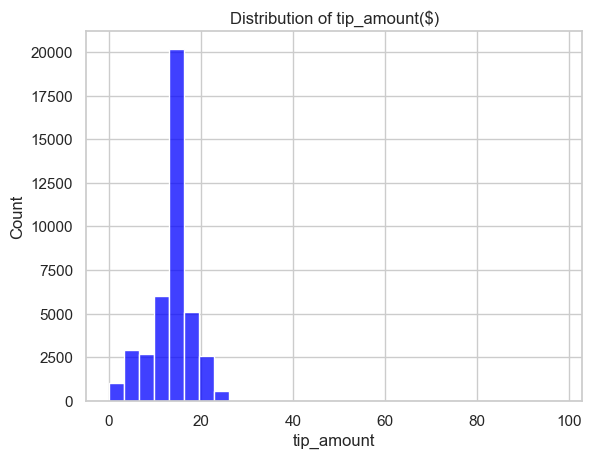

Lower bound:  0.7149999999999981
Upper bound:  25.475
Number of outliers:  386
Percentage of data:  0.9368477258385515 %


In [25]:

taxi['tip_amount'].describe()
sns.histplot(data=taxi, x="tip_amount", bins = 30,
             color="blue")
plt.title("Distribution of tip_amount($)")
plt.show()

#doing further analysis to ubderstand the dsitatibution
Q1 = taxi['tip_amount'].quantile(0.25)
Q3 = taxi['tip_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = taxi[(taxi['tip_amount'] < lower_bound) | (taxi['tip_amount'] > upper_bound)]


print("Lower bound: " ,lower_bound)
print("Upper bound: " ,upper_bound)
print("Number of outliers: ", len(outliers))
print("Percentage of data: ", (len(outliers)/len(taxi)) * 100,"%")

## Taxi Data Exploration: What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

The dataset has a shape of **41,202 rows and 13 columns**. Upon inspection, there are no null or missing values in any column. Using the describe() function, we obtained a 5-number statistical summary for each column.

The tip_amount histogram shows a **right-skewed distribution** ie tthe bulk of trips have tip amounts concentrated between **$10–$20**, with a long tail stretching toward $98, indicating a small number of unusually high tips.

Performing the IQR-based outlier calc, **Lower bound = $0.715, Upper bound = $25.475**

Since the minimum tip is **$0.01** and the maximum is **$98.00**, both bounds are violated, confirming the presence of outliers.There is total of **386 rows (0.94%) of the data** were identified as outliers. Since this represents less than 1% of the data, removing them will not significantly reduce the dataset size, but will prevent extreme values from biasing the regression model during training.